<a href="https://colab.research.google.com/github/ilyak0n/image_processing/blob/main/1/PR1_methods_OpenCV_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №1. Основные методы OpenCV. Часть №1**

---

# **Тема №1. Чтение, запись и отображение**

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np



## **Задание 1:**  
Напишите процедуру, которая:

- Считывает цветное изображение в режиме `cv2.IMREAD_COLOR`.
- Преобразует его в оттенки серого с использованием `cv2.cvtColor()`.
- Сохраняет полученное черно-белое изображение на диск.
- Отображает оба изображения (оригинальное цветное и преобразованное черно-белое).




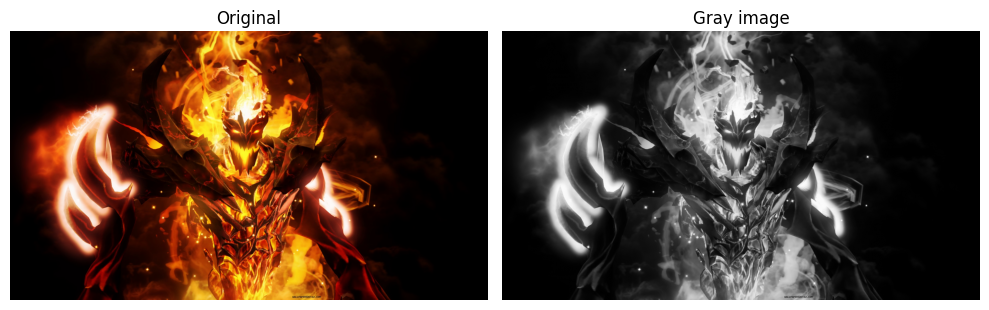

In [ ]:
def grayscaling(image_path):
  image = cv.imread(image_path, cv.IMREAD_COLOR)

  plt.figure(figsize=(10,8))

  plt.subplot(1, 2, 1)
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  plt.title('Original')
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2GRAY), cmap='gray')
  plt.title('Gray image')
  plt.axis('off')

  plt.tight_layout()
  plt.show()

  cv.imwrite('output_1.png', cv.cvtColor(image, cv.COLOR_BGR2GRAY))

grayscaling('38e71ad234602dab51db2e1390195b4f.jpg')

## **Задание 2:**  
Используя режим `cv2.IMREAD_UNCHANGED`, загрузите изображение с альфа-каналом (например, PNG с прозрачностью). Затем:

- Разделите изображение на каналы (B, G, R, A).
- Создайте новое изображение, где прозрачность (альфа-канал) инвертирована (т.е. прозрачные области становятся непрозрачными и наоборот).
- Сохраните и отобразите полученное изображение.

(2289, 2289, 4)


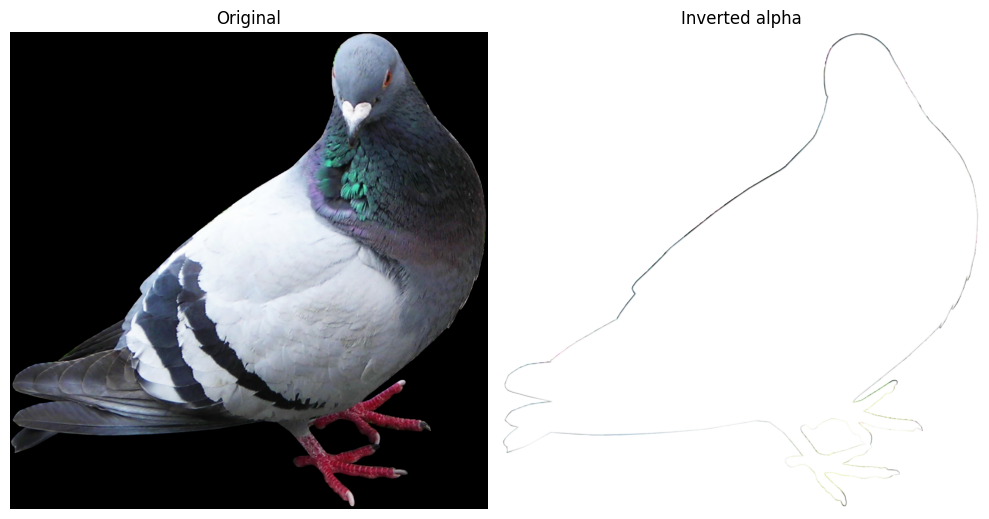

In [ ]:
image = cv.imread('306016798038211.png', cv.IMREAD_UNCHANGED)
print(image.shape)

plt.figure(figsize=(10,8))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

# image = ~image
inverted = cv.convertScaleAbs(image, alpha=-1, beta=255)
plt.subplot(1, 2, 2)
plt.imshow(inverted)
plt.title('Inverted alpha')
plt.axis('off')

plt.tight_layout()
plt.show()

---

# **Тема №2. Работа с цветовыми палитрами**



## **Задание 3:**  
Напишите процедуру, которая:

- Считывает цветное изображение.
- Преобразует его из цветового пространства BGR в HSV с помощью `cv2.cvtColor()`.
- Увеличивает насыщенность (канал S) в 1.5 раза, не превышая максимального значения.
- Преобразует изображение обратно в цветовое пространство BGR.
- Отображает оригинальное и полученное изображения рядом для сравнения.

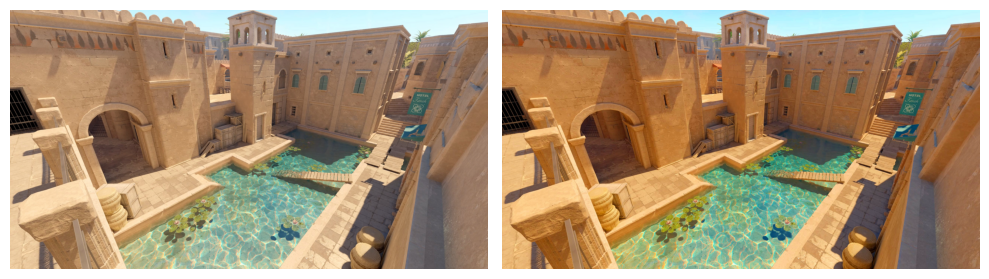

In [ ]:
def s_channel_enchantment(image_path):
  image = cv.imread(image_path, 1)
  hsv_image = cv.cvtColor(image, cv.COLOR_BGR2HSV)

  h, s, v = cv.split(hsv_image)
  s_new = cv.multiply(s, 1.5)
  multyplied_image = cv.merge((h, s_new, v))
  multyplied_image_rgb = cv.cvtColor(multyplied_image, cv.COLOR_HSV2RGB)

  plt.figure(figsize=(10,8))

  plt.subplot(1, 2, 1)
  plt.imshow(cv.cvtColor(hsv_image, cv.COLOR_HSV2RGB))
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(multyplied_image_rgb)
  plt.axis('off')

  plt.tight_layout()
  plt.show()

s_channel_enchantment('n74936.jpeg')

## **Задание 4:**  
Напишите процедуру, которая:

- Считывает изображение и Преобразует его в цветовое пространство YCrCb.
- Применяет размытие к компоненте яркости Y (при помощи фильтра, см. материал предыдущих занятий).
- Снова Преобразует изображение в цветовое пространство BGR.
- Отображает исходное и размытое изображения.

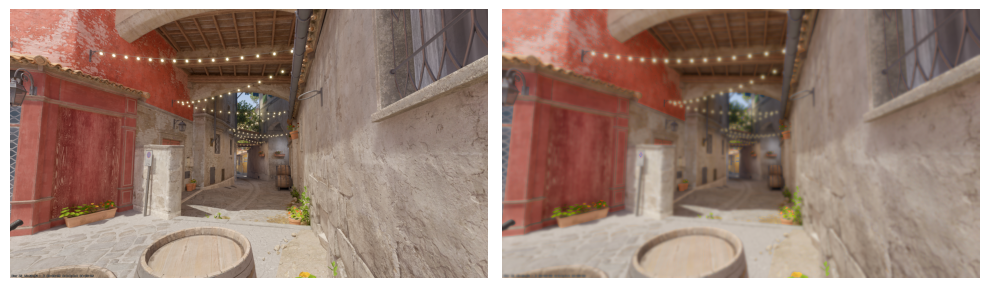

In [ ]:
def bluring(image_path):
  image = cv.imread(image_path)
  ycrcb_image = cv.cvtColor(image, cv.COLOR_RGB2YCrCb)

  y, cr, cb = cv.split(ycrcb_image)

  y_blurred = cv.GaussianBlur(y, (15,15), 0)
  blurred_image = cv.merge((y_blurred, cr, cb))
  blurred_image_rgb = cv.cvtColor(blurred_image, cv.COLOR_YCrCb2BGR)

  plt.figure(figsize=(10,8))

  plt.subplot(1,2,1)
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  plt.axis('off')

  plt.subplot(1,2,2)
  plt.imshow(blurred_image_rgb)
  plt.axis('off')

  plt.tight_layout()
  plt.show()

bluring('scale_1200.png')

---

# **Тема №3. Слияние и усиление**

## **Задание 5:**  
Создайте процедуру, которая:

- Считывает два изображения одинакового размера (можно подкорректировать с помощью метода `.resize()`).
- Выполняет побитовое ИЛИ (OR) над соответствующими пикселями двух изображений.
- Сохраняет и отображает результат операции.

(800, 800, 3) (800, 800, 3)


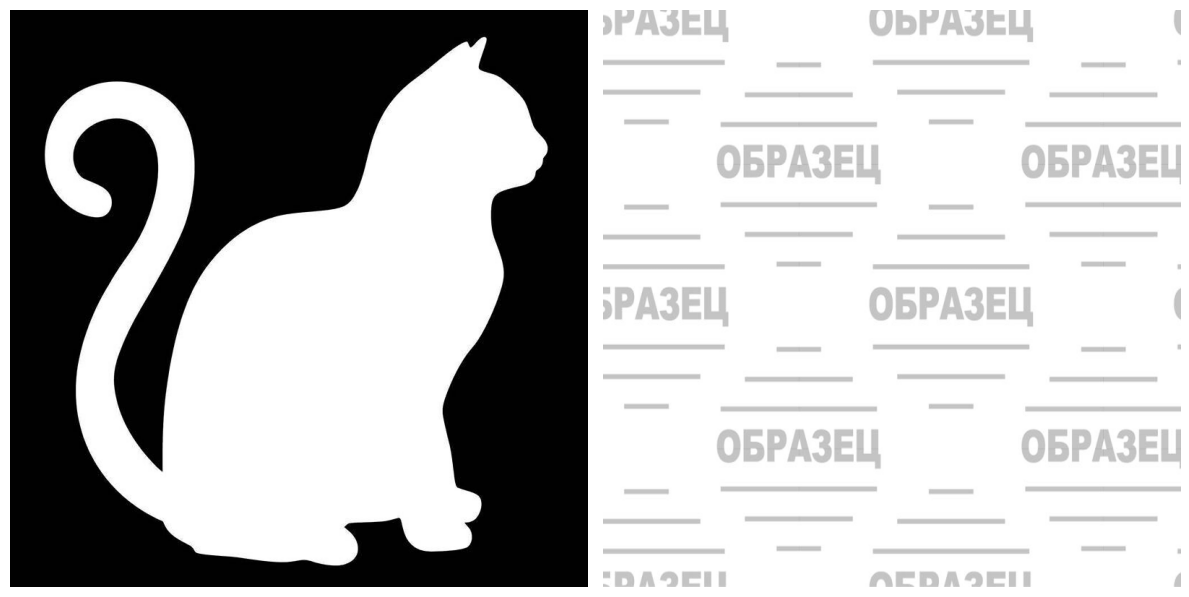

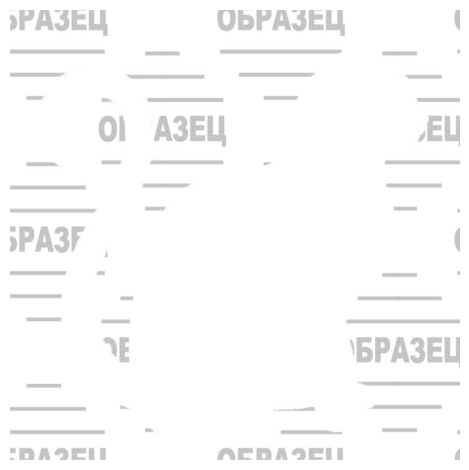

In [ ]:
def bitwising_or(img1, img2):
  img1 = cv.imread(img1)
  img2 = cv.imread(img2)

  resized_img2 = cv.resize(img2, (800, 800), interpolation=cv.INTER_CUBIC)
  print(img1.shape, resized_img2.shape)

  bitwise_or = cv.bitwise_or(img1, resized_img2)

  plt.figure(figsize=(12,9))

  plt.subplot(1,2,1)
  plt.imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
  plt.axis('off')

  plt.subplot(1,2,2)
  plt.imshow(cv.cvtColor(resized_img2, cv.COLOR_BGR2RGB))
  plt.axis('off')

  plt.tight_layout()
  plt.show()

  # plt.subplot(1,3,3)
  plt.imshow(bitwise_or)
  plt.axis('off')
  plt.tight_layout()
  plt.show()

bitwising_or('123456.jpg', '3654698.jpg')

## **Задание 6:**  
Реализуйте следующий алгоритм:

- Считайте цветное изображение и разделите его на три канала с использованием `.split()`.
- Примените к каждому каналу разный коэффициент гамма-коррекции (например, для R – 0.5, G – 1.0, B – 1.5).
- Объедините каналы обратно с помощью `.merge()`.
- Отобразите исходное и обработанное изображения.


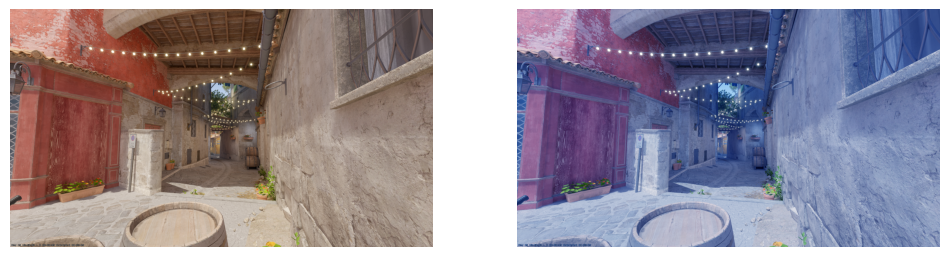

In [ ]:
image = cv.imread('scale_1200.png')
r, g, b = cv.split(image)

r_norm, g_norm, b_norm = r/255.0, g/255.0, b/255.0

r_corrected = np.power(r_norm, 0.5)
g_corrected = np.power(g_norm, 1.0)
b_corrected = np.power(b_norm, 1.5)

r_new, g_new, b_new = (r_corrected*255).astype(np.uint8), (g_corrected*255).astype(np.uint8), (b_corrected*255).astype(np.uint8)

new_image = cv.merge((r_new, g_new, b_new))

fig, ax = plt.subplots(1, 2, figsize=(12, 9))

ax[0].imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
ax[0].axis('off')

ax[1].imshow(cv.cvtColor(new_image, cv.COLOR_BGR2RGB))
ax[1].axis('off')

plt.show()

---

# **Тема №4. Работа с гистограммами в OpenCV**

## **Задание 7:**  
Напишите процедуру для улучшения контрастности изображения:

- Считывает изображение в оттенках серого.
- Строит его гистограмму с использованием `cv.calcHist()`.
- Применяет эквализацию гистограммы методом `cv2.equalizeHist()`.
- Отображает на одном графике исходное и эквализованное изображения вместе с их гистограммами.

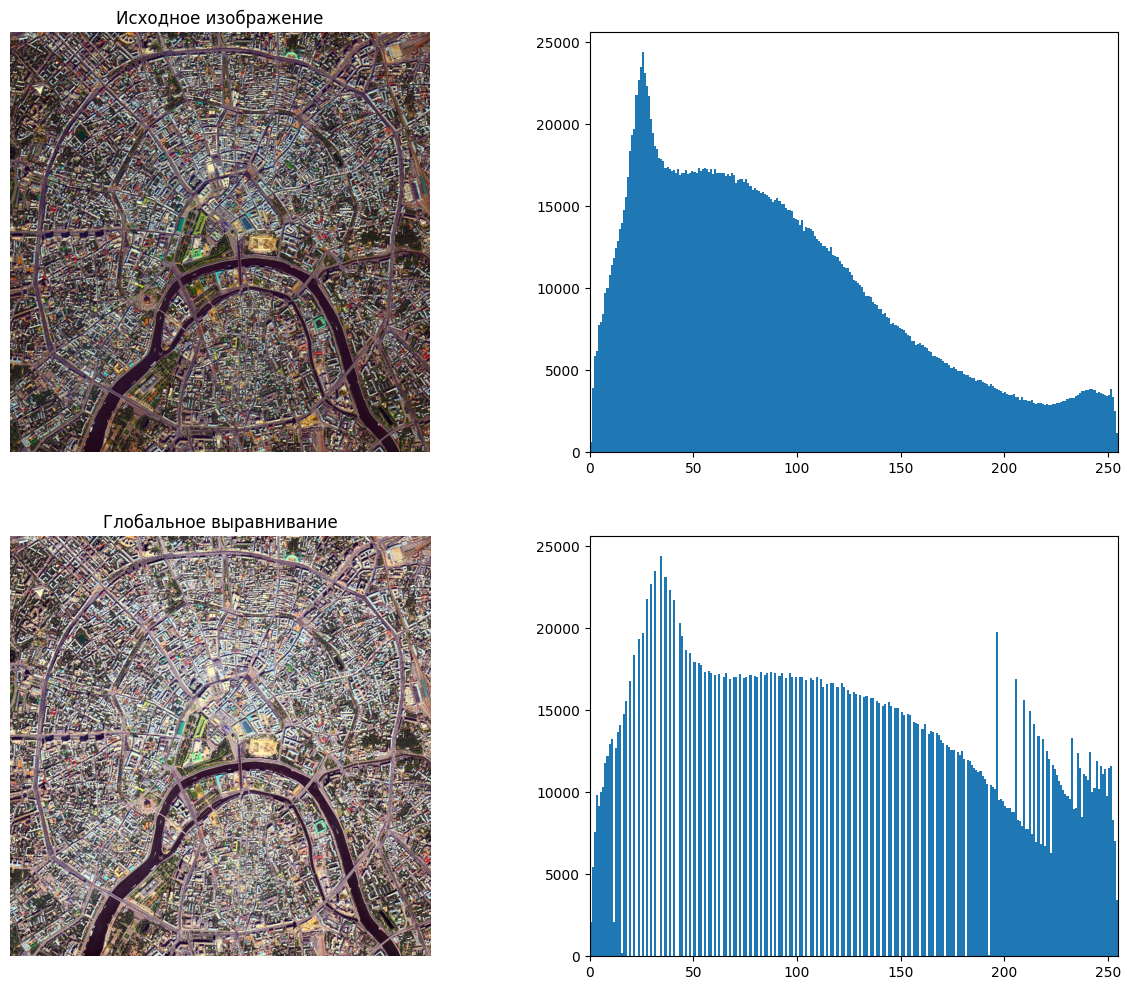

In [ ]:
def equalizing(image_path):
  image = cv.imread(image_path)

  gray1 = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
  hist = cv.calcHist(
      [gray1],
      [0],
      None,
      [256],
      [0, 256]
  )

  ycrcb_image = cv.cvtColor(image, cv.COLOR_BGR2YCrCb)
  ycrcb_equalized = ycrcb_image.copy()
  ycrcb_equalized[:, :, 0] = cv.equalizeHist(ycrcb_equalized[:, :, 0])
  equalized_image = cv.cvtColor(ycrcb_equalized, cv.COLOR_YCrCb2BGR)

  gray2 = cv.cvtColor(equalized_image, cv.COLOR_BGR2GRAY)
  hist = cv.calcHist(
      [gray2],
      [0],
      None,
      [256],
      [0, 256]
  )

  fig, axs = plt.subplots(2, 2, figsize=(15,12))

  axs[0,0].imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  axs[0,0].set_title("Исходное изображение")
  axs[0,0].axis('off')

  axs[0,1].hist(gray1.ravel(), bins=256, range=(0, 256))
  axs[0,1].set_xlim([0, 255])

  axs[1,0].imshow(cv.cvtColor(equalized_image, cv.COLOR_BGR2RGB))
  axs[1,0].set_title("Глобальное выравнивание")
  axs[1,0].axis('off')

  axs[1,1].hist(gray2.ravel(), bins=256, range=(0, 256))
  axs[1,1].set_xlim([0, 255])

  plt.show()

equalizing('msc.jpg')

## **Задание 8:**  
Используйте метод CLAHE для улучшения деталей в затемненных областях цветного изображения:

- Преобразуйте изображение из BGR в LAB цветовое пространство.
- Разделите изображение на каналы и примените `cv2.createCLAHE()` к каналу яркости L.
- Объедините обработанный канал L с исходными каналами A и B.
- Преобразуйте изображение обратно в BGR.
- Отобразите исходное и обработанное изображения для сравнения вместе с их гистограммами.

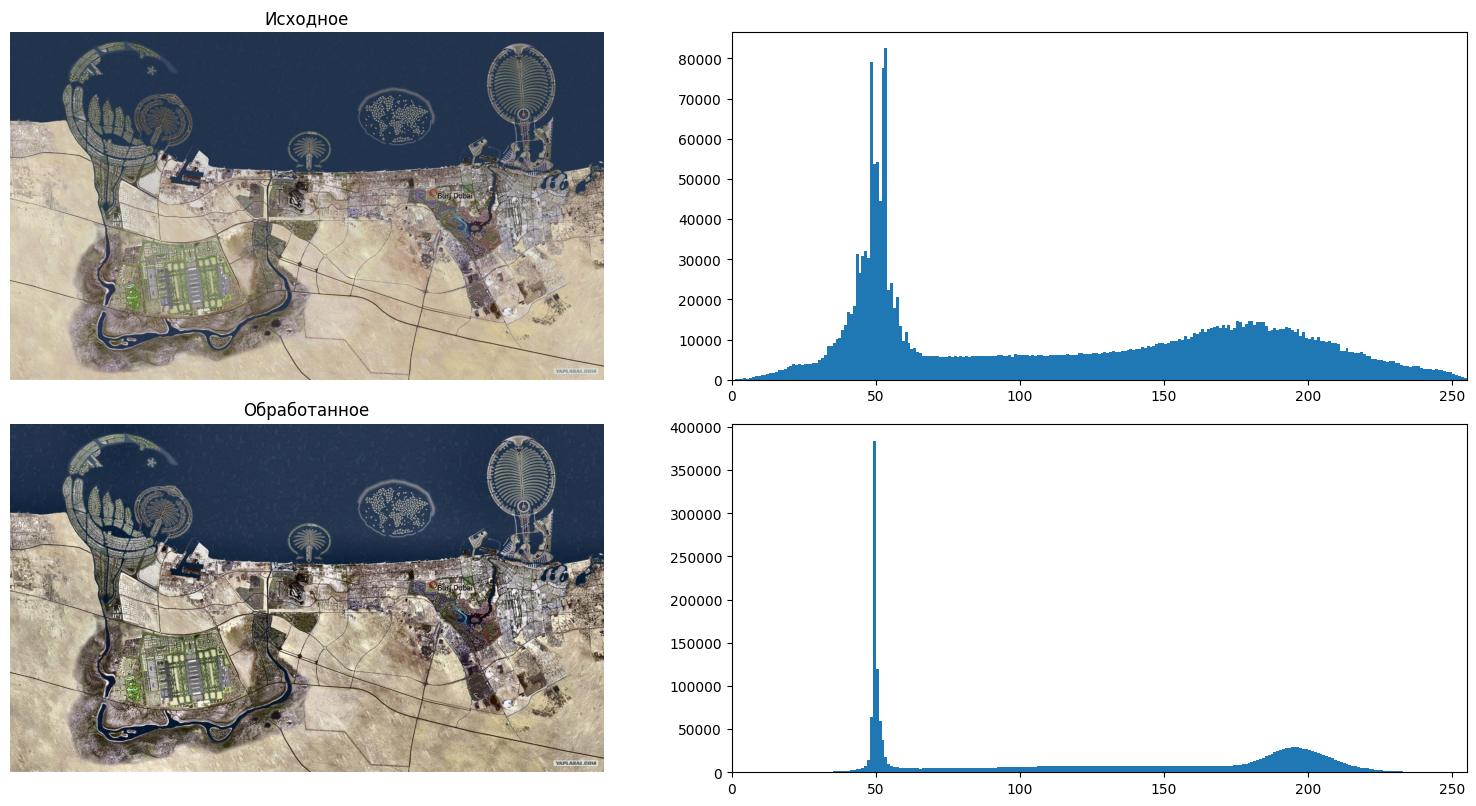

In [30]:
image = cv.imread('157806.jpg')

gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
hist = cv.calcHist(
    [gray_image],
    [0],
    None,
    [256],
    [0,256]
)

lab_img = cv.cvtColor(image, cv.COLOR_BGR2LAB)

l, a, b = cv.split(lab_img)

clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

l_clahe = l.copy()
l_clahe = clahe.apply(l)

new_lab_img = cv.merge((l_clahe, a, b))
new_image = cv.cvtColor(new_lab_img, cv.COLOR_LAB2BGR)

new_gray_image = cv.cvtColor(new_image, cv.COLOR_BGR2GRAY)
hist = cv.calcHist(
    [new_gray_image],
    [0],
    None,
    [256],
    [0,256]
)

fig, ax = plt.subplots(2, 2, figsize=(16,8))
fig.tight_layout()

ax[0,0].imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
ax[0,0].set_title('Исходное')
ax[0,0].axis('off')

ax[0,1].hist(new_gray_image.ravel(), bins=256, range=(0,256))
ax[0,1].set_xlim([0, 255])

ax[1,0].imshow(cv.cvtColor(new_image, cv.COLOR_BGR2RGB))
ax[1,0].set_title('Обработанное')
ax[1,0].axis('off')

ax[1,1].hist(gray_image.ravel(), bins=256, range=(0,256))
ax[1,1].set_xlim([0, 255])

plt.show()

## **Затем:**  
Исследуйте влияние размера окна (tileGridSize) и порога по сравнению с гистограммой (clipLimit) в методе CLAHE на конечный результат. Попробуйте несколько различных значений и визуализируйте результаты.


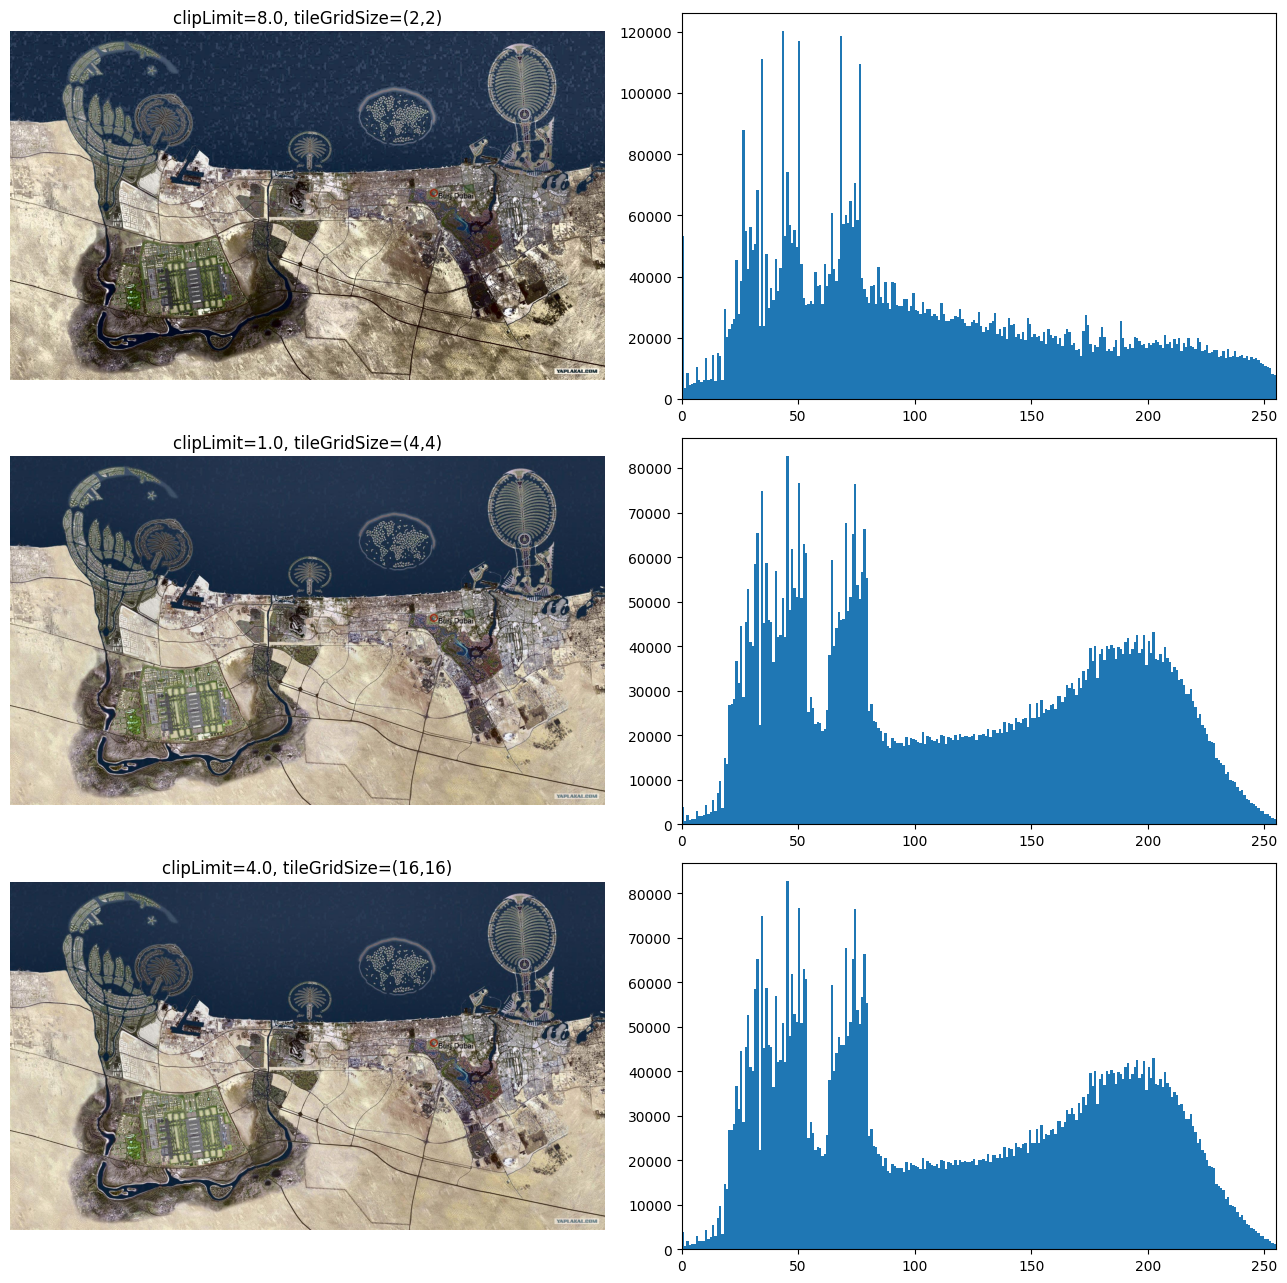

In [43]:
clahe_822 = cv.createCLAHE(clipLimit=8.0, tileGridSize=(2,2))
l_clahe_822 = l.copy()
l_clahe_822 = clahe_822.apply(l)

lab_image1 = cv.merge((l_clahe_822, a, b))
image1 = cv.cvtColor(lab_image1, cv.COLOR_LAB2BGR)

clahe_144 = cv.createCLAHE(clipLimit=1.0, tileGridSize=(4,4))
l_clahe_144 = l.copy()
l_clahe_144 = clahe_144.apply(l)

lab_image2 = cv.merge((l_clahe_144, a, b))
image2 = cv.cvtColor(lab_image2, cv.COLOR_LAB2BGR)

clahe_416 = cv.createCLAHE(clipLimit=4.0, tileGridSize=(16,16))
l_clahe_416 = l.copy()
l_clahe_416 = clahe_416.apply(l)

lab_image3 = cv.merge((l_clahe_416, a, b))
image3 = cv.cvtColor(lab_image3, cv.COLOR_LAB2BGR)


fig, ax = plt.subplots(3, 2, figsize=(13,13))

ax[0,0].imshow(cv.cvtColor(image1, cv.COLOR_BGR2RGB))
ax[0,0].set_title('clipLimit=8.0, tileGridSize=(2,2)')
ax[0,0].axis('off')

ax[0,1].hist(image1.ravel(), bins=256, range=(0,256))
ax[0,1].set_xlim([0,255])

ax[1,0].imshow(cv.cvtColor(image2, cv.COLOR_BGR2RGB))
ax[1,0].set_title('clipLimit=1.0, tileGridSize=(4,4)')
ax[1,0].axis('off')

ax[1,1].hist(image2.ravel(), bins=256, range=(0,256))
ax[1,1].set_xlim([0,255])

ax[2,0].imshow(cv.cvtColor(image2, cv.COLOR_BGR2RGB))
ax[2,0].set_title('clipLimit=4.0, tileGridSize=(16,16)')
ax[2,0].axis('off')

ax[2,1].hist(image2.ravel(), bins=256, range=(0,256))
ax[2,1].set_xlim([0,255])

plt.tight_layout()
plt.show()

---

# **Комплексное задание №1. Улучшение качества отсканированного документа с использованием OpenCV**



## **Краткое описание задания:**

- Необходимо написать функцию для улучшения качества отсканированного документа с использованием методов обработки изображений, изученных ранее. Функция должна принимать на вход изображение отсканированного документа и возвращать его улучшенную версию, готовую для дальнейшего использования, например, для распознавания текста.

Датасет с отсканированными изображениями можно найти в сети Интернет.

---



## **Алгоритм действий:**

#### **Реализуйте функцию на языке Python с использованием библиотеки OpenCV, которая выполняет следующие этапы обработки:**

### **1. Чтение, запись и отображение изображений:**

- Функция должна принимать на вход изображение отсканированного документа (например, в формате JPEG или PNG)
- Проверьте наличие альфа-канала в изображении и, если он присутствует, загрузите изображение в режиме `cv2.IMREAD_UNCHANGED`, иначе используйте `cv2.IMREAD_COLOR`
- Отобразите исходное изображение для визуальной проверки

### **2. Работа с цветовыми палитрами:**

- Преобразуйте изображение в оттенки серого, используя `cv2.cvtColor()` с параметром `cv2.COLOR_BGR2GRAY`.
- Отобразите полученное изображение в оттенках серого.

### **3. Слияние и усиление:**

- Примените медианный фильтр (`cv2.medianBlur()`) для удаления шумов с изображения. Выберите подходящий размер ядра (например, 3 или 5). Отобразите результат.
- Используйте фильтр сглаживания с применением прямой свертки (`cv2.filter2D()`) с заданным ядром для повышения четкости. Например, можно использовать фильтр "Unsharp Masking":
  - Создайте ядро для повышения резкости. Пример ядра:
    ```python
    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]])
    ```
  - Примените фильтр к изображению и отобразите результат.

### **4. Работа с гистограммами:**

- Примените метод CLAHE (Contrast Limited Adaptive Histogram Equalization) для улучшения контрастности изображения:
  - Создайте объект CLAHE с параметрами `clipLimit=2.0` и `tileGridSize=(8,8)`.
  - Примените CLAHE к изображению.
  - отобразите результат.
- Постройте гистограммы яркости исходного и обработанного изображений для сравнения.

---

### **Требования к функции:**

- Функция должна называться: `improve_scan(image)`, где `image` — входное изображение в виде массива NumPy.
- Функция должна возвращать улучшенное изображение в виде массива NumPy.
- В ходе работы функция должна **опционально** отображать промежуточные результаты для наглядности (в условиях Colab использовать соответствующие методы вывода изображений). Для этого следует ввести отдельный параметр (например: `visible=True`) и реализовать с ним соответствующую логику.

---

### **Дополнительные требования:**

- **Обработка ошибок:**
  - Убедитесь, что функция корректно обрабатывает ситуации, когда на вход подается некорректное изображение.
  - Добавьте проверки на тип входных данных.

- **Документация и комментарии:**
  - Функция должна быть снабжена понятной документацией: опишите, какие преобраования выполняются и для чего.
  - Добавьте комментарии к основным участкам кода для пояснения выполняемых действий.



---

### **Подсказки и рекомендации:**


- **Медианный фильтр:**
  Функция `cv2.medianBlur(src, ksize)` принимает на вход изображение и размер ядра (должен быть нечетным числом).

- **CLAHE:**
  - Создайте объект CLAHE с помощью `cv2.createCLAHE(clipLimit, tileGridSize)`.
  - Примените метод `apply()` к изображению в оттенках серого.

- **Отображение изображений в Google Colab:**
  - Используйте `matplotlib.pyplot` для отображения изображений.
  - Помните, что `cv2.imread()` загружает изображения в формате BGR, поэтому для корректного отображения в Matplotlib Преобразуйте изображение в RGB с помощью `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`.

---

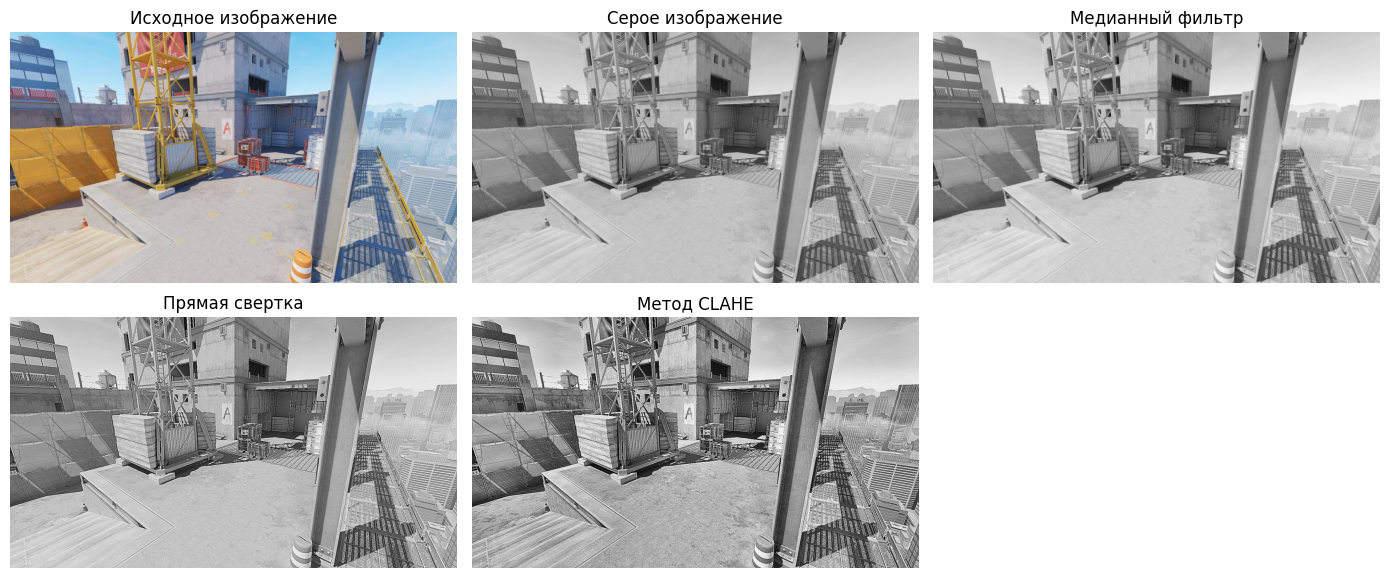

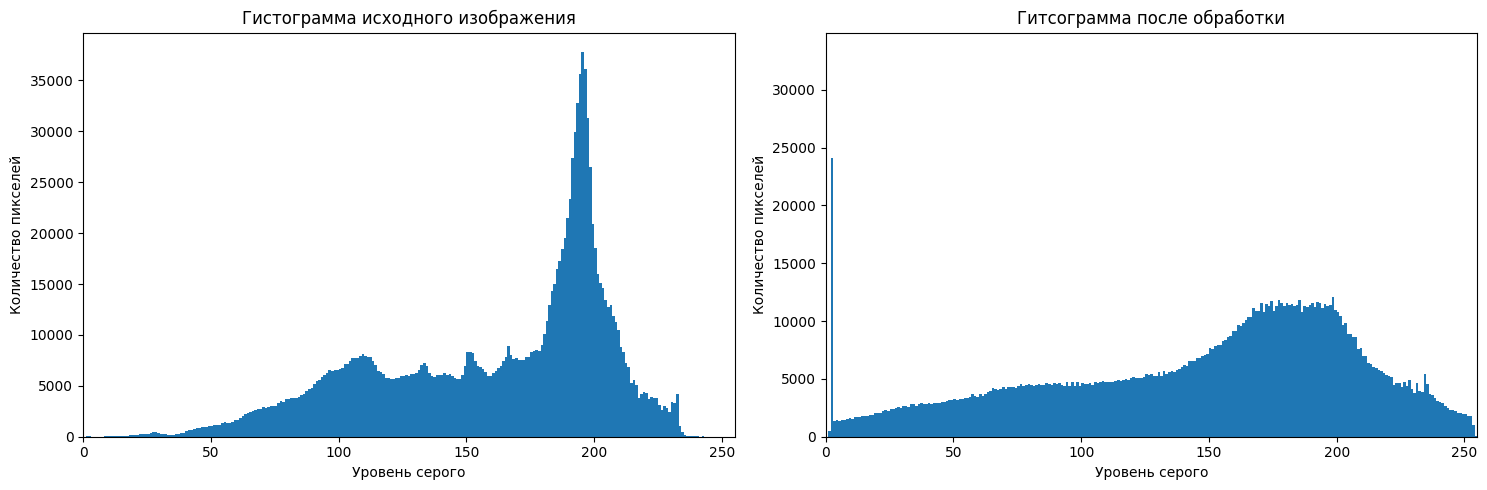

In [28]:
def improve_scan(image_path, visible=True):
  # 1. чтение и запись
  image = cv.imread(image_path)

  if len(image.shape) == 3 and image.shape[2] == 4:
    print("Изображение загружено с альфа-каналом")
  else:
    image = cv.imread(image_path, cv.IMREAD_COLOR)

  # 2. работа с цветовыми палитрами
  gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

  # 3. слияние и усиление
  processed_image_3d = cv.medianBlur(gray_image, 3)

  kernel = np.array([[-1, -1, -1],
                    [-1,  9, -1],
                    [-1, -1, -1]])
  processed_image_2d = cv.filter2D(processed_image_3d, -1, kernel)

  #4. работа с гистограммами
  clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

  clahe_eq_img = clahe.apply(processed_image_2d)

  #5. отображение
  if visible:
    plt.figure(figsize=(14,6))

    plt.subplot(2,3,1)
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.title('Исходное изображение')
    plt.axis('off')

    plt.subplot(2,3,2)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Серое изображение')
    plt.axis("off")

    plt.subplot(2,3,3)
    plt.imshow(processed_image_3d, cmap='gray')
    plt.title('Медианный фильтр')
    plt.axis("off")

    plt.subplot(2,3,4)
    plt.imshow(processed_image_2d, cmap='gray')
    plt.title('Прямая свертка')
    plt.axis("off")

    plt.subplot(2,3,5)
    plt.imshow(clahe_eq_img, cmap='gray')
    plt.title('Метод CLAHE')
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # hist1 = cv.calcHist([gray_image], [0], None, [256], [0, 256])
    # hist2 = cv.calcHist([clahe_eq_img], [0], None, [256], [0, 256])

    plt.figure(figsize=(15,5))

    plt.subplot(1,2,1)
    plt.hist(gray_image.ravel(), bins=256, range=(0,256))
    plt.xlim([0,255])
    plt.xlabel("Уровень серого")
    plt.ylabel("Количество пикселей")
    plt.title('Гистограмма исходного изображения')

    plt.subplot(1,2,2)
    plt.hist(clahe_eq_img.ravel(), bins=256, range=(0,256))
    plt.xlim([0,255])
    plt.xlabel("Уровень серого")
    plt.ylabel("Количество пикселей")
    plt.title('Гитсограмма после обработки')

    plt.tight_layout()
    plt.show()

  else:
    plt.figure(figsize=(14,6))

    plt.subplot(1,2,1)
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.title('Исходное изображение')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(clahe_eq_img, cmap='gray')
    plt.title('Метод CLAHE')
    plt.axis("off")

    plt.tight_layout()
    plt.show()

improve_scan("vertigo.jpeg")

## **Дополнительное задание:**

- Поэкспериментируйте с параметрами медианного фильтра, ядром для фильтра повышения резкости и параметрами CLAHE для достижения наилучшего результата.
- Добавьте возможность передачи этих параметров в функцию `improve_scan` для более гибкой настройки обработки. **В качестве параметров по умолчанию установите те, которые показали себя лучше всего по результатам экспериментов**

**Пример с параметрами:**

```python
def improve_scan(image,
                 median_kernel_size=3,
                 sharp_kernel= np.array([[-1, -1, -1],
                                         [-1,  9, -1],
                                         [-1, -1, -1]]),
                 clahe_clip=2.0,
                 clahe_grid=(8,8),
                 visible=True):
    # Реализация с учетом переданных параметров
    ...
```


In [ ]:
# Ваш код